In [1]:
import pandas as pd

In [2]:
CORPUS_URL='https://github.com/Magallanes-at-UTDT/texts/raw/main/data/processed/RawCorpus.csv'
corpus = pd.read_csv(CORPUS_URL)

In [3]:
corpus.head()

,party,text_raw,n_characters,n_words
0,AhoraNacion,\n \n \n \n \nAHORA NACIÓN \nPLAN DE GOBIERNO...,373258,53720
1,BuenGobierno,\n1 \n \n \n \n \n \n \n \n \n \n \nPARTIDO D...,221197,28149
2,FuerzaPopular,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n ...,327610,44266
3,JuntosPorElPeru,...,215489,30513
4,Obras,\n1 \n \n \n \nPLAN DE GOBIERNO 2026–2031 \nP...,40765,5583


Preprocessing

In [4]:
corpus["text_bow"] = corpus["text_raw"]

# to lower case all text
corpus["text_bow"] = corpus["text_bow"].str.lower()

# remove punctuation
import re
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"[^\w\s]",
    " ",
    regex=True
)

# Remove standalone one- or two-digit numbers
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"\b\d{1,2}\b",
    " ",
    regex=True
)

# white space normalization (one in between words)
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"\s+",
    " ",
    regex=True
)



The regex `\s` means **any whitespace character**, including:

* space (` `)
* tab (`\t`)
* newline (`\n`)
* carriage return (`\r`)




In [5]:
corpus["tokens_bow"] = corpus["text_bow"].str.split()

corpus.iloc[0,]

party                                                 AhoraNacion
text_raw         \n \n \n \n \nAHORA NACIÓN \nPLAN DE GOBIERNO...
n_characters                                               373258
n_words                                                     53720
text_bow         ahora nación plan de gobierno 2026 2031 firma...
tokens_bow      [ahora, nación, plan, de, gobierno, 2026, 2031...
Name: 0, dtype: object

In [6]:
corpus["n_tokens_before"] = corpus["tokens_bow"].str.len()

In [7]:
# ! pip install nltk

In [8]:
import nltk 
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/josemanuelmagallanes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
from nltk.corpus import stopwords

spanish_stopwords = set(stopwords.words("spanish"))

In [10]:
sorted(spanish_stopwords)[:30]

['a',
 'al',
 'algo',
 'algunas',
 'algunos',
 'ante',
 'antes',
 'como',
 'con',
 'contra',
 'cual',
 'cuando',
 'de',
 'del',
 'desde',
 'donde',
 'durante',
 'e',
 'el',
 'ella',
 'ellas',
 'ellos',
 'en',
 'entre',
 'era',
 'erais',
 'eran',
 'eras',
 'eres',
 'es']

In [11]:
corpus["tokens_bow"] = corpus["tokens_bow"].apply(
    lambda words: [w for w in words if w not in spanish_stopwords]
)

In [12]:
corpus["n_tokens_after"] = corpus["tokens_bow"].str.len()

In [13]:
corpus["tokens_removed"] = (
    corpus["n_tokens_before"] -
    corpus["n_tokens_after"]
)

corpus["reduction_pct"] = (
    corpus["tokens_removed"] /
    corpus["n_tokens_before"] *
    100
)

In [14]:
corpus[
    [
        "party",
        "n_tokens_before",
        "n_tokens_after",
        "tokens_removed",
        "reduction_pct"
    ]
]

,party,n_tokens_before,n_tokens_after,tokens_removed,reduction_pct
0,AhoraNacion,51561,29957,21604,41.899886
1,BuenGobierno,25636,17017,8619,33.620690
2,FuerzaPopular,44239,27499,16740,37.839915
3,JuntosPorElPeru,29612,16697,12915,43.614075
4,Obras,5412,3246,2166,40.022173
5,RenovacionPopular,6828,3850,2978,43.614528


<Axes: xlabel='% of tokens removed', ylabel='party'>

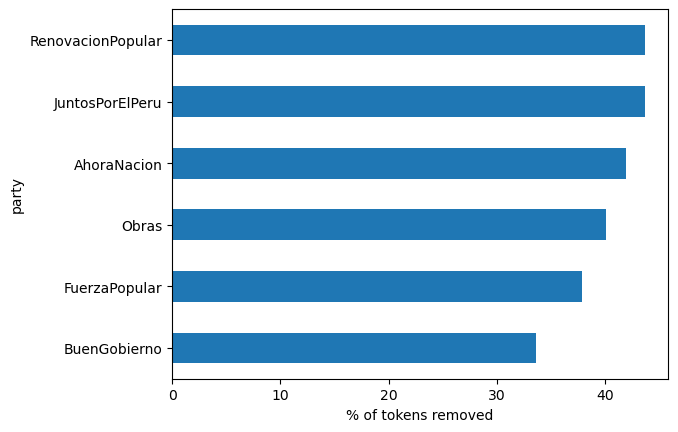

In [15]:
corpus[["party", "reduction_pct"]].sort_values("reduction_pct").set_index("party") \
    .plot.barh(legend=False,xlabel="% of tokens removed")

In [16]:
from collections import Counter

word_counts = Counter(corpus.loc[0, "tokens_bow"])
word_counts.most_common(20)

[('nacional', 328),
 ('desarrollo', 250),
 ('porcentaje', 197),
 ('meta', 189),
 ('sistema', 177),
 ('país', 165),
 ('perú', 159),
 ('problema', 145),
 ('servicios', 142),
 ('estratégico', 137),
 ('objetivo', 135),
 ('estrategia', 134),
 ('acceso', 130),
 ('plan', 118),
 ('uso', 113),
 ('número', 113),
 ('sostenible', 112),
 ('salud', 106),
 ('social', 104),
 ('gestión', 101)]

<Axes: xlabel='Frequency'>

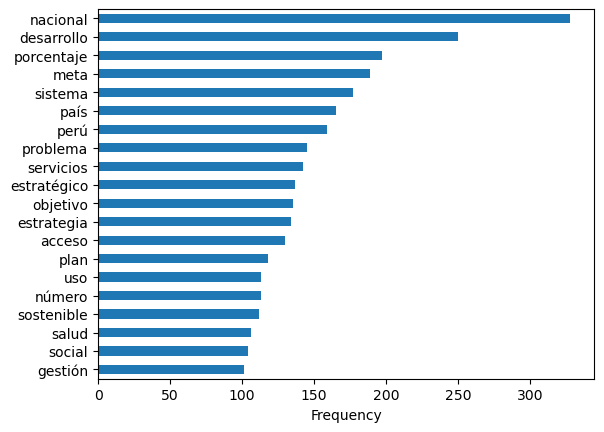

In [17]:
word_counts_df = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

(
    word_counts_df
    .sort_values("count")
    .set_index("word")
    .plot.barh(
        legend=False,
        xlabel="Frequency",
        ylabel=""
    )
)

In [18]:
corpus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   party            6 non-null      object 
 1   text_raw         6 non-null      object 
 2   n_characters     6 non-null      int64  
 3   n_words          6 non-null      int64  
 4   text_bow         6 non-null      object 
 5   tokens_bow       6 non-null      object 
 6   n_tokens_before  6 non-null      int64  
 7   n_tokens_after   6 non-null      int64  
 8   tokens_removed   6 non-null      int64  
 9   reduction_pct    6 non-null      float64
dtypes: float64(1), int64(5), object(4)
memory usage: 612.0+ bytes


| Column            | Purpose                           |
| ----------------- | --------------------------------- |
| `party`           | Document identifier               |
| `text_raw`        | Original text                     |
| `n_characters`    | Size of original document         |
| `n_words`         | Initial word count                |
| `text_bow`        | Preprocessed text                 |
| `tokens_bow`      | Bag-of-words token representation |
| `n_tokens_before` | Tokens before stopword removal    |
| `n_tokens_after`  | Tokens after stopword removal     |
| `tokens_removed`  | Number of removed stopwords       |
| `reduction_pct`   | Percentage of removed tokens      |


In [19]:
from pathlib import Path

PROCESSED_DIR = Path("data/processed")
corpus.to_pickle(
    PROCESSED_DIR / "corpus_raw_bow.pkl"
)